# MNIST Image Denoising using Autoencoders

This notebook implements three autoencoder architectures to remove Gaussian noise from MNIST handwritten digit images.

**Models:**
1. Feed-Forward Neural Network (FFNN) Autoencoder
2. Transpose Convolutional (CNN) Autoencoder
3. Upsampled Convolutional (CNN) Autoencoder

The autoencoders are trained to map noisy images back to their clean originals, learning a robust compressed representation that captures the essential structure of handwritten digits.

## 1. Importing Required Packages

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, SubsetRandomSampler
import torch.optim
from torchvision import datasets, transforms

%matplotlib inline

## 2. Configuration

In [2]:
# Hyperparameters
BATCH_SIZE = 64
EPOCHS = 20
LEARNING_RATE = 0.001
NOISE_FACTOR = 0.5
VALID_SIZE = 0.2
NUM_WORKERS = 0
RANDOM_SEED = 42

# Auto-detect best available device
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

print(f"Using device: {DEVICE}")

# Reproducibility
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

# Dataset path — using the provided mnist_png folder
DATA_DIR = os.path.join(os.path.dirname(os.path.abspath('.')), 'mnist_png')
TRAIN_DIR = os.path.join(DATA_DIR, 'training')
TEST_DIR = os.path.join(DATA_DIR, 'testing')

# Output directories
MODELS_DIR = os.path.join('.', 'models')
RESULTS_DIR = os.path.join('.', 'results')
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"Training data: {TRAIN_DIR}")
print(f"Testing data:  {TEST_DIR}")

Using device: mps
Training data: /Users/adi/Documents/celebal internship/Week6/mnist_png/training
Testing data:  /Users/adi/Documents/celebal internship/Week6/mnist_png/testing


## 3. Loading Data from mnist_png

The dataset is organized as PNG files in folders by digit label (0-9):
```
mnist_png/
├── training/
│   ├── 0/  (5923 images)
│   ├── 1/  (6742 images)
│   └── ...  
└── testing/
    ├── 0/  (980 images)
    ├── 1/  (1135 images)
    └── ...
```

We use `torchvision.datasets.ImageFolder` to load these images, converting them to grayscale tensors normalized to [0, 1].

In [3]:
# Define transforms: convert to grayscale (in case), then to tensor (normalizes to [0,1])
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor()
])

# Load datasets using ImageFolder
train_data = datasets.ImageFolder(TRAIN_DIR, transform=transform)
test_data = datasets.ImageFolder(TEST_DIR, transform=transform)

print(f"Training samples: {len(train_data)}")
print(f"Testing samples:  {len(test_data)}")
print(f"Classes: {train_data.classes}")

Training samples: 60000
Testing samples:  10000
Classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


## 4. Defining DataLoaders

We split the training data 80/20 into train and validation sets using `SubsetRandomSampler`.

In [4]:
# Split training data into train and validation sets
train_length = len(train_data)
indices = list(range(train_length))
np.random.shuffle(indices)
split = int(np.floor(VALID_SIZE * train_length))
train_idx, valid_idx = indices[split:], indices[:split]

# Define samplers
train_sampler = SubsetRandomSampler(train_idx)
valid_sampler = SubsetRandomSampler(valid_idx)

# Create DataLoaders
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE,
                          sampler=train_sampler, num_workers=NUM_WORKERS)
valid_loader = DataLoader(train_data, batch_size=BATCH_SIZE,
                          sampler=valid_sampler, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE,
                         num_workers=NUM_WORKERS)

print(f"Train batches: {len(train_loader)}, "
      f"Validation batches: {len(valid_loader)}, "
      f"Test batches: {len(test_loader)}")

Train batches: 750, Validation batches: 188, Test batches: 157


## 5. Checking Data Shape

In [5]:
# Verify data shape
dataiter = iter(train_loader)
images, labels = next(dataiter)
print(f"Batch shape: {images.shape}")
print(f"Single image shape: {images[0].shape}")
print(f"Pixel value range: [{images.min():.2f}, {images.max():.2f}]")
print(f"Labels: {labels[:10]}")

Batch shape: torch.Size([64, 1, 28, 28])
Single image shape: torch.Size([1, 28, 28])
Pixel value range: [0.00, 1.00]
Labels: tensor([0, 2, 0, 0, 8, 3, 8, 5, 4, 2])


## 6. Visualizing a Training Batch

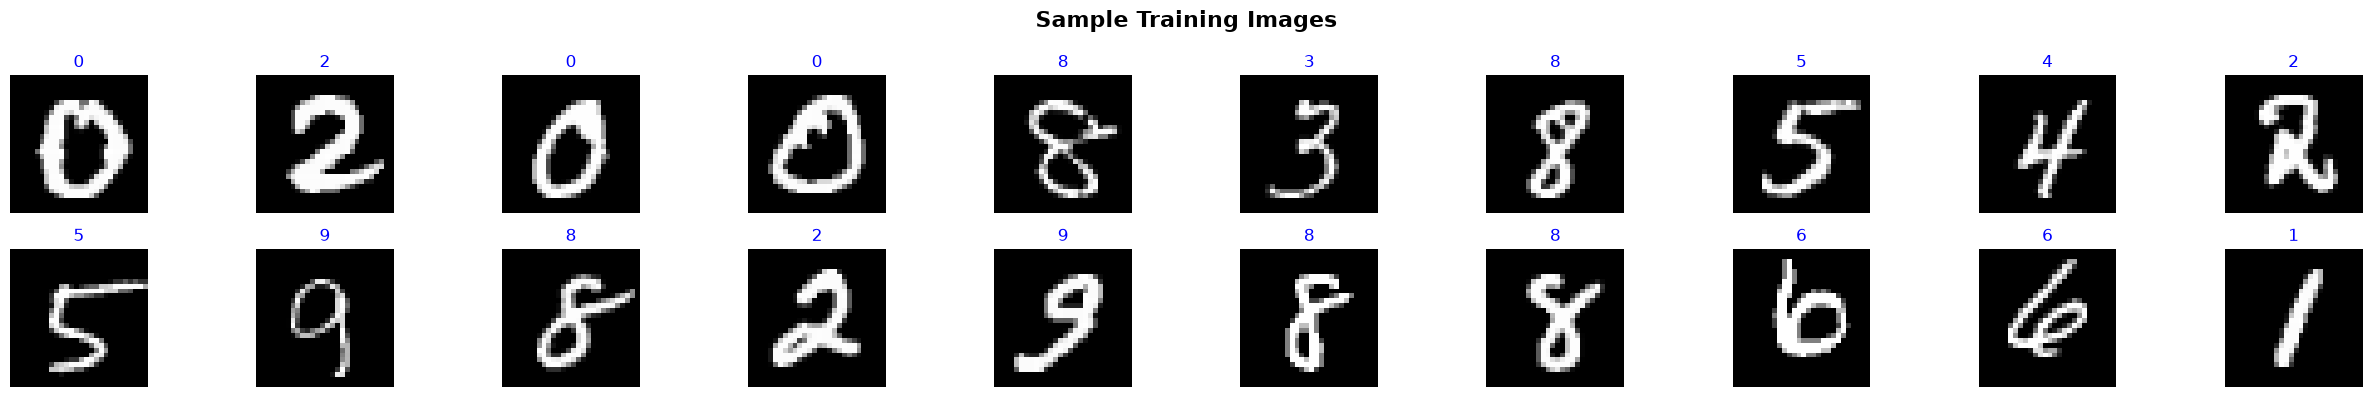

In [6]:
fig = plt.figure(figsize=(25, 4))
for i in range(20):
    ax = fig.add_subplot(2, 10, i + 1)
    ax.imshow(images[i].numpy().squeeze(), cmap='gray')
    ax.set_title(str(labels[i].item()), color='blue')
    ax.axis('off')
plt.suptitle('Sample Training Images', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Noise Addition Utility

We add Gaussian noise to images to create the noisy inputs. The autoencoder will learn to remove this noise.

In [7]:
def add_noise(images, noise_factor=NOISE_FACTOR):
    """
    Add Gaussian noise to images and clamp to [0, 1].
    
    Args:
        images: Tensor of shape (B, C, H, W) with values in [0, 1]
        noise_factor: Standard deviation of the Gaussian noise
    
    Returns:
        Noisy images clamped to [0, 1]
    """
    noisy = images + noise_factor * torch.randn_like(images)
    return torch.clamp(noisy, 0.0, 1.0)

### Visualizing Noisy vs Clean Images

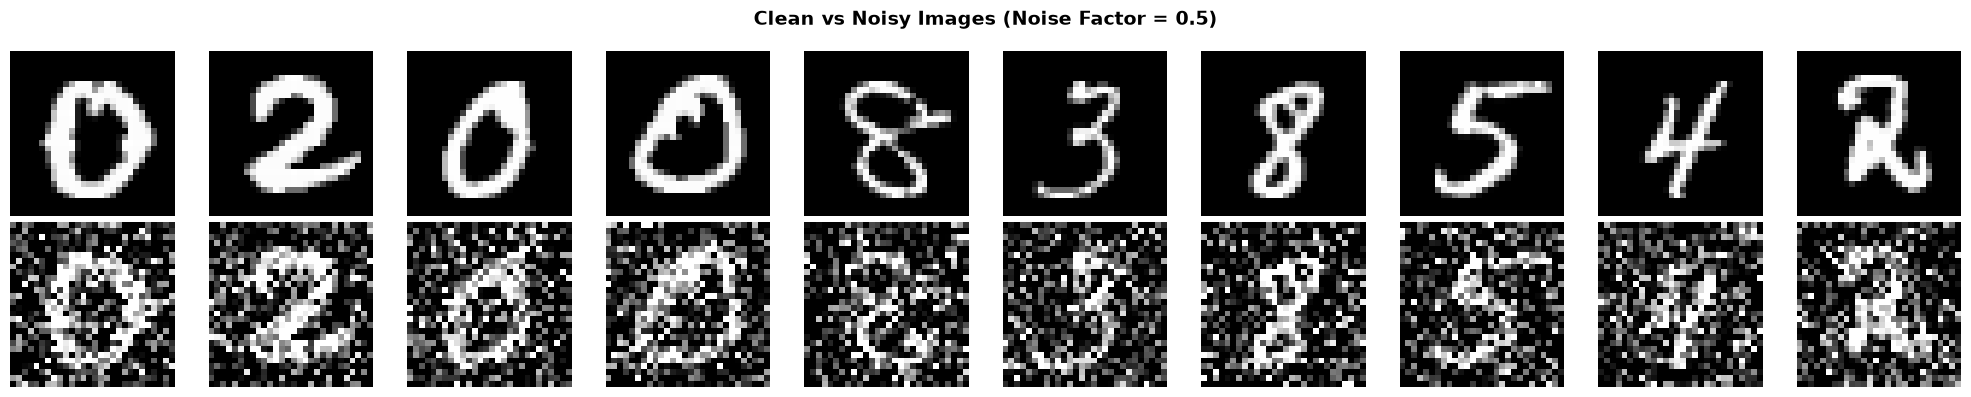

In [8]:
# Show clean vs noisy
noisy_samples = add_noise(images)

fig, axes = plt.subplots(2, 10, figsize=(20, 4))
for i in range(10):
    axes[0, i].imshow(images[i].squeeze(), cmap='gray')
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_ylabel('Clean', fontsize=12, fontweight='bold')
    
    axes[1, i].imshow(noisy_samples[i].squeeze(), cmap='gray')
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_ylabel('Noisy', fontsize=12, fontweight='bold')

plt.suptitle(f'Clean vs Noisy Images (Noise Factor = {NOISE_FACTOR})',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Model Definitions

We define three autoencoder architectures, each with different decoder strategies.

### Model 1: Feed-Forward Neural Network (FFNN) Autoencoder

- Flattens 28×28 images into 784-dim vectors
- **Encoder**: 784 → 256 → 64 → 32 (ReLU activations)
- **Decoder**: 32 → 64 → 256 → 784 (ReLU + final Sigmoid)

In [9]:
class FFNNAutoencoder(nn.Module):
    """
    Feed-Forward Neural Network Autoencoder.
    Images are flattened to 784-dimensional vectors.
    """
    def __init__(self, encoding_dim=32):
        super(FFNNAutoencoder, self).__init__()
        # Encoder layers
        self.enc1 = nn.Linear(784, 256)
        self.enc2 = nn.Linear(256, 64)
        self.enc3 = nn.Linear(64, encoding_dim)

        # Decoder layers
        self.dec1 = nn.Linear(encoding_dim, 64)
        self.dec2 = nn.Linear(64, 256)
        self.dec3 = nn.Linear(256, 784)

    def forward(self, x):
        # Flatten input
        x = x.view(x.size(0), -1)
        # Encode
        x = F.relu(self.enc1(x))
        x = F.relu(self.enc2(x))
        x = F.relu(self.enc3(x))
        # Decode
        x = F.relu(self.dec1(x))
        x = F.relu(self.dec2(x))
        x = torch.sigmoid(self.dec3(x))
        # Reshape back to image
        x = x.view(x.size(0), 1, 28, 28)
        return x

### Model 2: Transpose CNN Autoencoder

- Works directly on 2D image data (preserves spatial structure)
- **Encoder**: Conv2d(1→16) → MaxPool → Conv2d(16→4) → MaxPool → 4×7×7
- **Decoder**: ConvTranspose2d(4→16) → ConvTranspose2d(16→1) → 1×28×28

Note: Transpose convolutions can produce checkerboard artifacts.

In [10]:
class TransposeCNNAutoencoder(nn.Module):
    """
    Convolutional Autoencoder using Transpose Convolutions for upsampling.
    Encoder: 1x28x28 -> 16x14x14 -> 4x7x7
    Decoder: 4x7x7 -> 16x14x14 -> 1x28x28
    """
    def __init__(self):
        super(TransposeCNNAutoencoder, self).__init__()
        # Encoder
        self.en_conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.en_conv2 = nn.Conv2d(16, 4, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

        # Decoder (transpose convolutions)
        self.de_conv1 = nn.ConvTranspose2d(4, 16, 2, stride=2)
        self.de_conv2 = nn.ConvTranspose2d(16, 1, 2, stride=2)

    def forward(self, x):
        # Encode
        x = self.pool(F.relu(self.en_conv1(x)))
        x = self.pool(F.relu(self.en_conv2(x)))
        # Decode
        x = F.relu(self.de_conv1(x))
        x = torch.sigmoid(self.de_conv2(x))
        return x

### Model 3: Upsampled CNN Autoencoder

- Same encoder as Model 2
- **Decoder**: Uses nearest-neighbor upsampling + standard Conv2d
- Avoids the checkerboard artifacts of transpose convolutions
- BatchNorm is used in the decoder to stabilize gradient flow

In [11]:
class UpsampledCNNAutoencoder(nn.Module):
    """
    Convolutional Autoencoder using Nearest-Neighbor Upsampling + Conv.
    Avoids checkerboard artifacts from transpose convolutions.
    Uses BatchNorm for stable gradient flow.
    """
    def __init__(self):
        super(UpsampledCNNAutoencoder, self).__init__()
        # Encoder
        self.en_conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.en_conv2 = nn.Conv2d(16, 4, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

        # Decoder (upsample + conv with BatchNorm)
        self.upsample = nn.Upsample(scale_factor=2, mode='nearest')
        self.de_conv1 = nn.Conv2d(4, 16, 3, padding=1)
        self.de_bn1 = nn.BatchNorm2d(16)
        self.de_conv2 = nn.Conv2d(16, 1, 3, padding=1)

    def forward(self, x):
        # Encode
        x = self.pool(F.relu(self.en_conv1(x)))
        x = self.pool(F.relu(self.en_conv2(x)))
        # Decode
        x = self.upsample(x)
        x = F.relu(self.de_bn1(self.de_conv1(x)))
        x = self.upsample(x)
        x = torch.sigmoid(self.de_conv2(x))
        return x

# Since the images are normalized between 0 and 1, we use a sigmoid 
# activation on the output layer to get values that match this range.

## 9. Model Instantiation & Weight Initialization

In [12]:
# Initialize models
model_1 = FFNNAutoencoder(encoding_dim=32)
model_2 = TransposeCNNAutoencoder()
model_3 = UpsampledCNNAutoencoder()

# Weight initialization for FFNN
def weight_init_normal(m):
    """
    Initialize weights for Linear layers using Normal distribution.
    For a layer with n input features, weights ~ Normal(0, 1/sqrt(n)).
    """
    if isinstance(m, nn.Linear):
        n = m.in_features
        y = 1.0 / np.sqrt(n)
        m.weight.data.normal_(0, y)
        m.bias.data.fill_(0)

model_1.apply(weight_init_normal)

# Move models to device
model_1 = model_1.to(DEVICE)
model_2 = model_2.to(DEVICE)
model_3 = model_3.to(DEVICE)

print("Model 1 - FFNN Autoencoder:")
print(model_1)
print(f"\nModel 2 - Transpose CNN Autoencoder:")
print(model_2)
print(f"\nModel 3 - Upsampled CNN Autoencoder:")
print(model_3)
print(f"\nDevice: {DEVICE}")

Model 1 - FFNN Autoencoder:
FFNNAutoencoder(
  (enc1): Linear(in_features=784, out_features=256, bias=True)
  (enc2): Linear(in_features=256, out_features=64, bias=True)
  (enc3): Linear(in_features=64, out_features=32, bias=True)
  (dec1): Linear(in_features=32, out_features=64, bias=True)
  (dec2): Linear(in_features=64, out_features=256, bias=True)
  (dec3): Linear(in_features=256, out_features=784, bias=True)
)

Model 2 - Transpose CNN Autoencoder:
TransposeCNNAutoencoder(
  (en_conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (en_conv2): Conv2d(16, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (de_conv1): ConvTranspose2d(4, 16, kernel_size=(2, 2), stride=(2, 2))
  (de_conv2): ConvTranspose2d(16, 1, kernel_size=(2, 2), stride=(2, 2))
)

Model 3 - Upsampled CNN Autoencoder:
UpsampledCNNAutoencoder(
  (en_conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), pad

## 10. Loss Function

We use MSE (Mean Squared Error) loss since we're comparing pixel values — this is a regression task measuring per-pixel reconstruction quality.

In [13]:
criterion = nn.MSELoss()

## 11. Training Function

The key difference from standard autoencoders: we feed **noisy images** as input and compare the output to the **original clean images**. This forces the model to learn to denoise.

In [14]:
def train_denoising(model, model_name):
    """
    Train a denoising autoencoder model.
    
    The model receives noisy images as input and is trained to
    reconstruct the original clean images using MSE loss.
    
    Args:
        model: The autoencoder model (already on DEVICE)
        model_name: Name for saving the model
    
    Returns:
        Dictionary with 'train' and 'valid' loss lists
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    
    loss_history = {'train': [], 'valid': []}
    valid_loss_min = np.inf
    
    print(f"\n{'='*60}")
    print(f"Training: {model_name}")
    print(f"{'='*60}")
    
    for epoch in range(EPOCHS):
        train_loss = 0.0
        valid_loss = 0.0
        
        # --- Training Phase ---
        model.train()
        for images, _ in train_loader:
            images = images.to(DEVICE)
            
            # Add noise to create the input (target remains clean)
            noisy_images = add_noise(images)
            
            optimizer.zero_grad()
            output = model(noisy_images)
            loss = criterion(output, images)  # Compare output to CLEAN images
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        
        # --- Validation Phase ---
        model.eval()
        with torch.no_grad():
            for images, _ in valid_loader:
                images = images.to(DEVICE)
                noisy_images = add_noise(images)
                output = model(noisy_images)
                loss = criterion(output, images)
                valid_loss += loss.item()
        
        # Average loss per batch
        train_loss /= len(train_loader)
        valid_loss /= len(valid_loader)
        
        loss_history['train'].append(train_loss)
        loss_history['valid'].append(valid_loss)
        
        print(f"Epoch {epoch+1:2d}/{EPOCHS}  |  "
              f"Train Loss: {train_loss:.6f}  |  "
              f"Valid Loss: {valid_loss:.6f}", end="")
        
        # Save best model
        if valid_loss <= valid_loss_min:
            print(f"  \u2713 Saved (improved from {valid_loss_min:.6f})")
            save_path = os.path.join(MODELS_DIR, f"{model_name}.pth")
            torch.save(model.state_dict(), save_path)
            valid_loss_min = valid_loss
        else:
            print()
    
    print(f"Best validation loss: {valid_loss_min:.6f}")
    return loss_history

## 12. Training Model 1: FFNN Autoencoder

In [15]:
m1_loss = train_denoising(model_1, 'FFNN_Autoencoder')


Training: FFNN_Autoencoder


Epoch  1/20  |  Train Loss: 0.044152  |  Valid Loss: 0.031651  ✓ Saved (improved from inf)


Epoch  2/20  |  Train Loss: 0.029378  |  Valid Loss: 0.027553  ✓ Saved (improved from 0.031651)


Epoch  3/20  |  Train Loss: 0.026024  |  Valid Loss: 0.025016  ✓ Saved (improved from 0.027553)


Epoch  4/20  |  Train Loss: 0.023912  |  Valid Loss: 0.023110  ✓ Saved (improved from 0.025016)


...

Epoch 16/20  |  Train Loss: 0.018040  |  Valid Loss: 0.017918  ✓ Saved (improved from 0.018260)


Epoch 17/20  |  Train Loss: 0.017890  |  Valid Loss: 0.017801  ✓ Saved (improved from 0.017918)


Epoch 18/20  |  Train Loss: 0.017735  |  Valid Loss: 0.018419


Epoch 19/20  |  Train Loss: 0.017619  |  Valid Loss: 0.017744  ✓ Saved (improved from 0.017801)


Epoch 20/20  |  Train Loss: 0.017514  |  Valid Loss: 0.017416  ✓ Saved (improved from 0.017744)
Best validation loss: 0.017416


## 13. Training Model 2: Transpose CNN Autoencoder

In [16]:
m2_loss = train_denoising(model_2, 'TransposeCNN_Autoencoder')


Training: TransposeCNN_Autoencoder


Epoch  1/20  |  Train Loss: 0.069153  |  Valid Loss: 0.040691  ✓ Saved (improved from inf)


Epoch  2/20  |  Train Loss: 0.038698  |  Valid Loss: 0.037660  ✓ Saved (improved from 0.040691)


Epoch  3/20  |  Train Loss: 0.037208  |  Valid Loss: 0.036692  ✓ Saved (improved from 0.037660)


Epoch  4/20  |  Train Loss: 0.036407  |  Valid Loss: 0.036100  ✓ Saved (improved from 0.036692)


...

Epoch 16/20  |  Train Loss: 0.032142  |  Valid Loss: 0.032052  ✓ Saved (improved from 0.032232)


Epoch 17/20  |  Train Loss: 0.031874  |  Valid Loss: 0.031743  ✓ Saved (improved from 0.032052)


Epoch 18/20  |  Train Loss: 0.031689  |  Valid Loss: 0.031576  ✓ Saved (improved from 0.031743)


Epoch 19/20  |  Train Loss: 0.031515  |  Valid Loss: 0.031435  ✓ Saved (improved from 0.031576)


Epoch 20/20  |  Train Loss: 0.031380  |  Valid Loss: 0.031325  ✓ Saved (improved from 0.031435)
Best validation loss: 0.031325


## 14. Training Model 3: Upsampled CNN Autoencoder

In [17]:
m3_loss = train_denoising(model_3, 'UpsampledCNN_Autoencoder')


Training: UpsampledCNN_Autoencoder


Epoch  1/20  |  Train Loss: 0.028399  |  Valid Loss: 0.018722  ✓ Saved (improved from inf)


Epoch  2/20  |  Train Loss: 0.017502  |  Valid Loss: 0.016851  ✓ Saved (improved from 0.018722)


Epoch  3/20  |  Train Loss: 0.016525  |  Valid Loss: 0.016251  ✓ Saved (improved from 0.016851)


Epoch  4/20  |  Train Loss: 0.016091  |  Valid Loss: 0.016054  ✓ Saved (improved from 0.016251)


...

Epoch 16/20  |  Train Loss: 0.014989  |  Valid Loss: 0.015063


Epoch 17/20  |  Train Loss: 0.014918  |  Valid Loss: 0.014884  ✓ Saved (improved from 0.014973)


Epoch 18/20  |  Train Loss: 0.014930  |  Valid Loss: 0.015029


Epoch 19/20  |  Train Loss: 0.014888  |  Valid Loss: 0.014883  ✓ Saved (improved from 0.014884)


Epoch 20/20  |  Train Loss: 0.014885  |  Valid Loss: 0.016655
Best validation loss: 0.014883


## 15. Loading Best Models

In [18]:
model_1.load_state_dict(torch.load(os.path.join(MODELS_DIR, 'FFNN_Autoencoder.pth'),
                                   map_location=DEVICE, weights_only=True))
model_2.load_state_dict(torch.load(os.path.join(MODELS_DIR, 'TransposeCNN_Autoencoder.pth'),
                                   map_location=DEVICE, weights_only=True))
model_3.load_state_dict(torch.load(os.path.join(MODELS_DIR, 'UpsampledCNN_Autoencoder.pth'),
                                   map_location=DEVICE, weights_only=True))
print("All best models loaded successfully!")

All best models loaded successfully!


## 16. Plotting Loss Curves

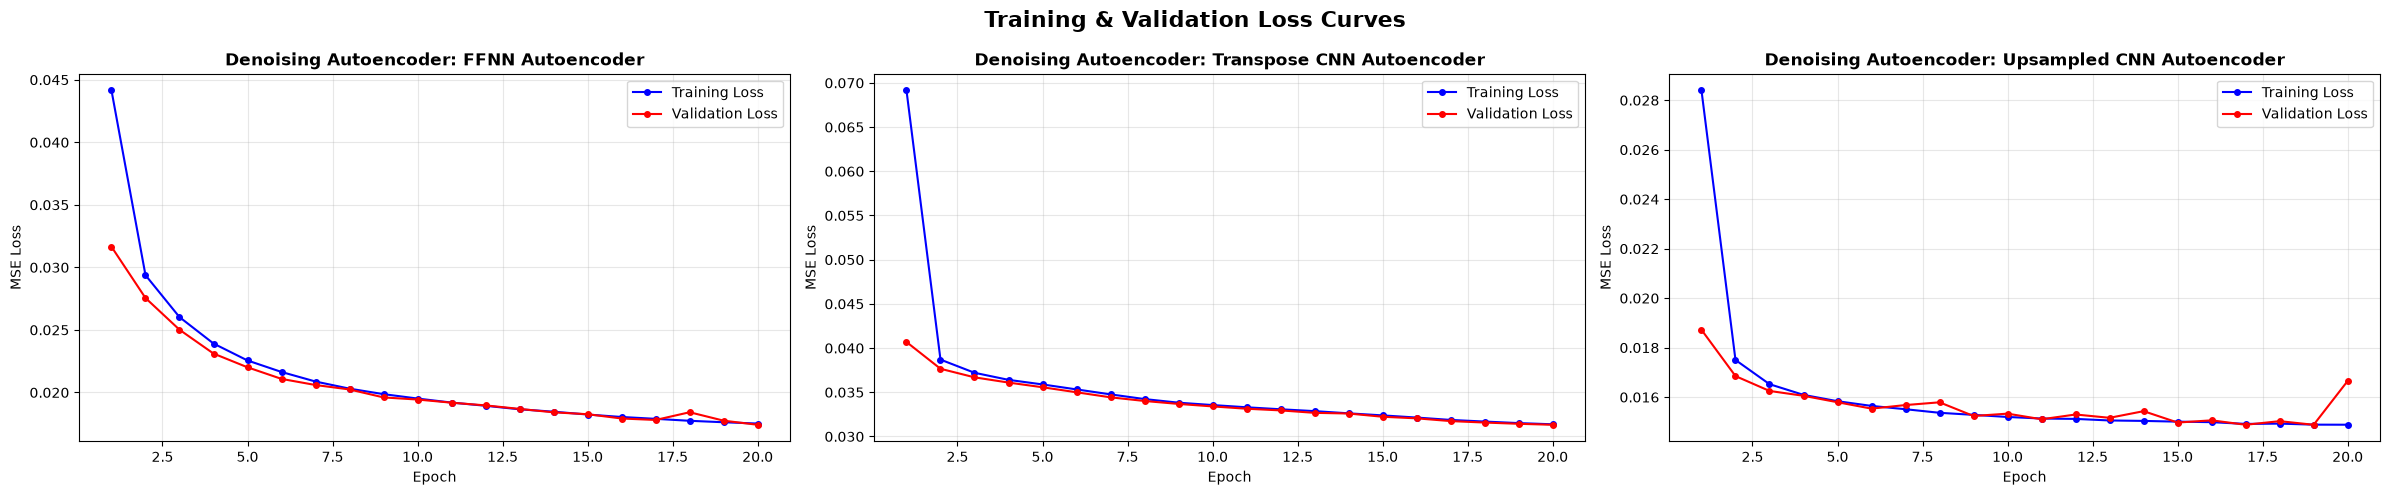

In [19]:
titles = ['FFNN Autoencoder', 'Transpose CNN Autoencoder', 'Upsampled CNN Autoencoder']
model_losses = [m1_loss, m2_loss, m3_loss]

fig, axes = plt.subplots(1, 3, figsize=(24, 5))

for ax, losses, title in zip(axes, model_losses, titles):
    epochs_range = range(1, len(losses['train']) + 1)
    ax.plot(epochs_range, losses['train'], 'b-o', markersize=4, label='Training Loss')
    ax.plot(epochs_range, losses['valid'], 'r-o', markersize=4, label='Validation Loss')
    ax.set_title(f'Denoising Autoencoder: {title}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Training & Validation Loss Curves', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'loss_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

## 17. Denoising Results Visualization

For each model, we show three rows:
- **Row 1**: Original clean images
- **Row 2**: Noisy images (with Gaussian noise)
- **Row 3**: Denoised output from the autoencoder

In [20]:
def visualize_denoising(model, model_name):
    """
    Visualize denoising results: Original / Noisy / Denoised.
    Shows 10 sample images in three rows.
    """
    model.eval()
    dataiter = iter(test_loader)
    images, _ = next(dataiter)
    images = images.to(DEVICE)
    
    # Generate noisy images
    noisy_images = add_noise(images)
    
    # Get denoised output
    with torch.no_grad():
        denoised = model(noisy_images)
    
    # Move to CPU for plotting
    images_np = images.cpu().numpy()
    noisy_np = noisy_images.cpu().numpy()
    denoised_np = denoised.cpu().numpy()
    
    # Plot 10 examples
    n_display = 10
    fig, axes = plt.subplots(nrows=3, ncols=n_display, figsize=(20, 6))
    
    row_labels = ['Original', 'Noisy', 'Denoised']
    for row_idx, (data, label) in enumerate(
        zip([images_np, noisy_np, denoised_np], row_labels)):
        for i in range(n_display):
            ax = axes[row_idx, i]
            ax.imshow(np.squeeze(data[i]), cmap='gray')
            ax.get_xaxis().set_visible(False)
            ax.get_yaxis().set_visible(False)
            if i == 0:
                ax.set_ylabel(label, fontsize=14, fontweight='bold')
    
    fig.suptitle(f'Denoising Results \u2014 {model_name}', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, f'{model_name}_denoising.png'),
                dpi=150, bbox_inches='tight')
    plt.show()

### Test FFNN Autoencoder

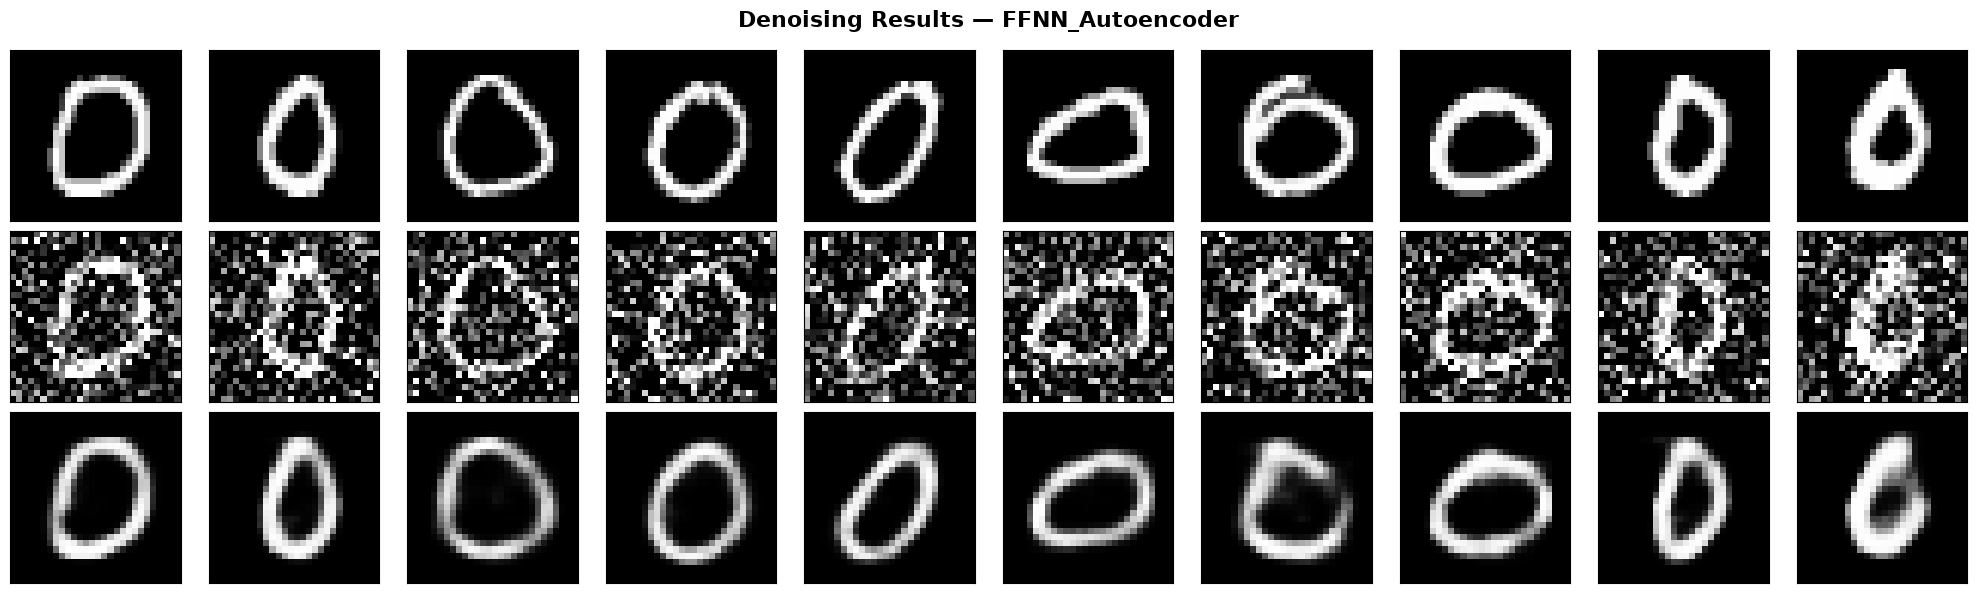

In [21]:
visualize_denoising(model_1, 'FFNN_Autoencoder')

### Test Transpose CNN Autoencoder

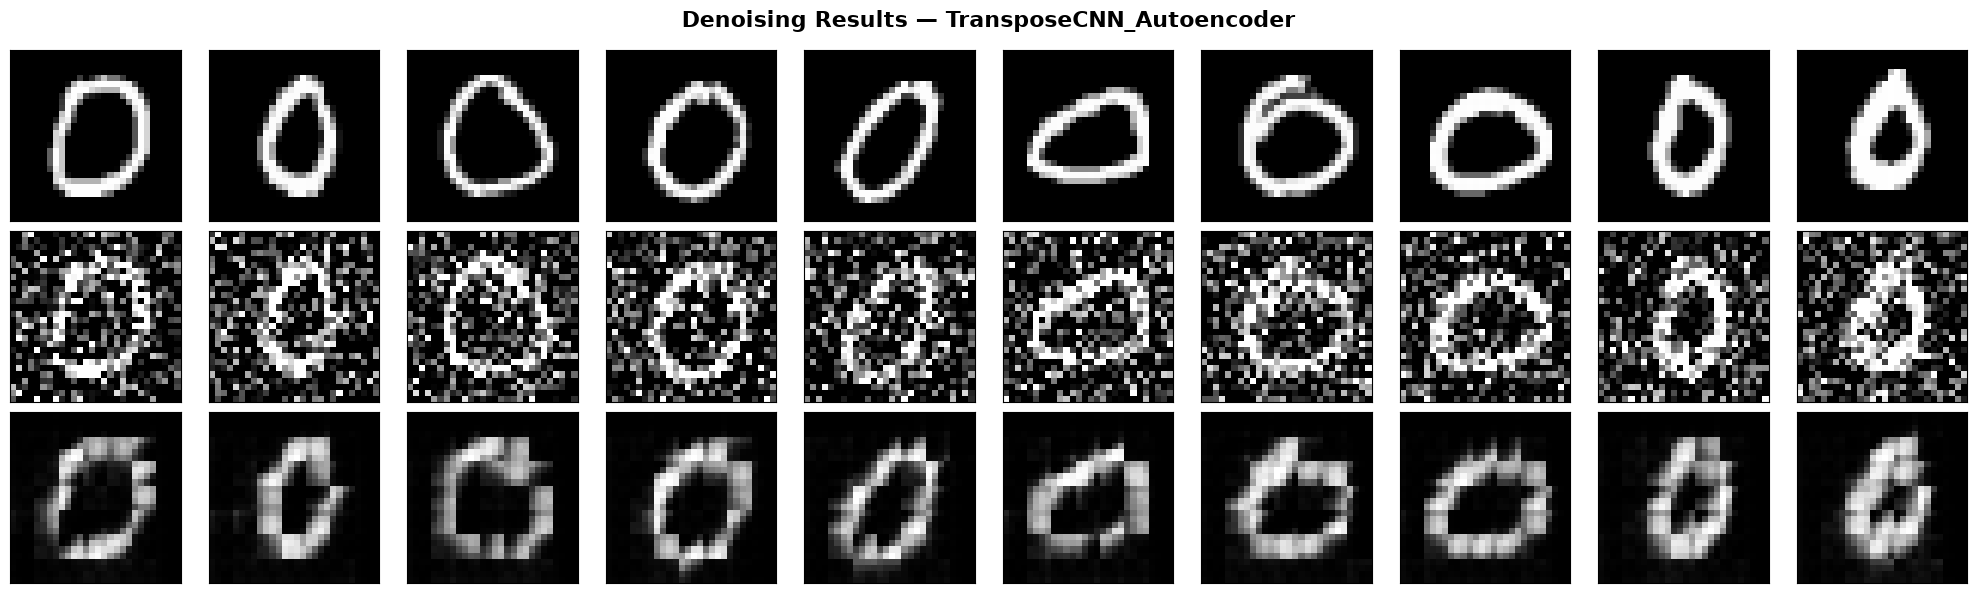

In [22]:
visualize_denoising(model_2, 'TransposeCNN_Autoencoder')

### Test Upsampled CNN Autoencoder

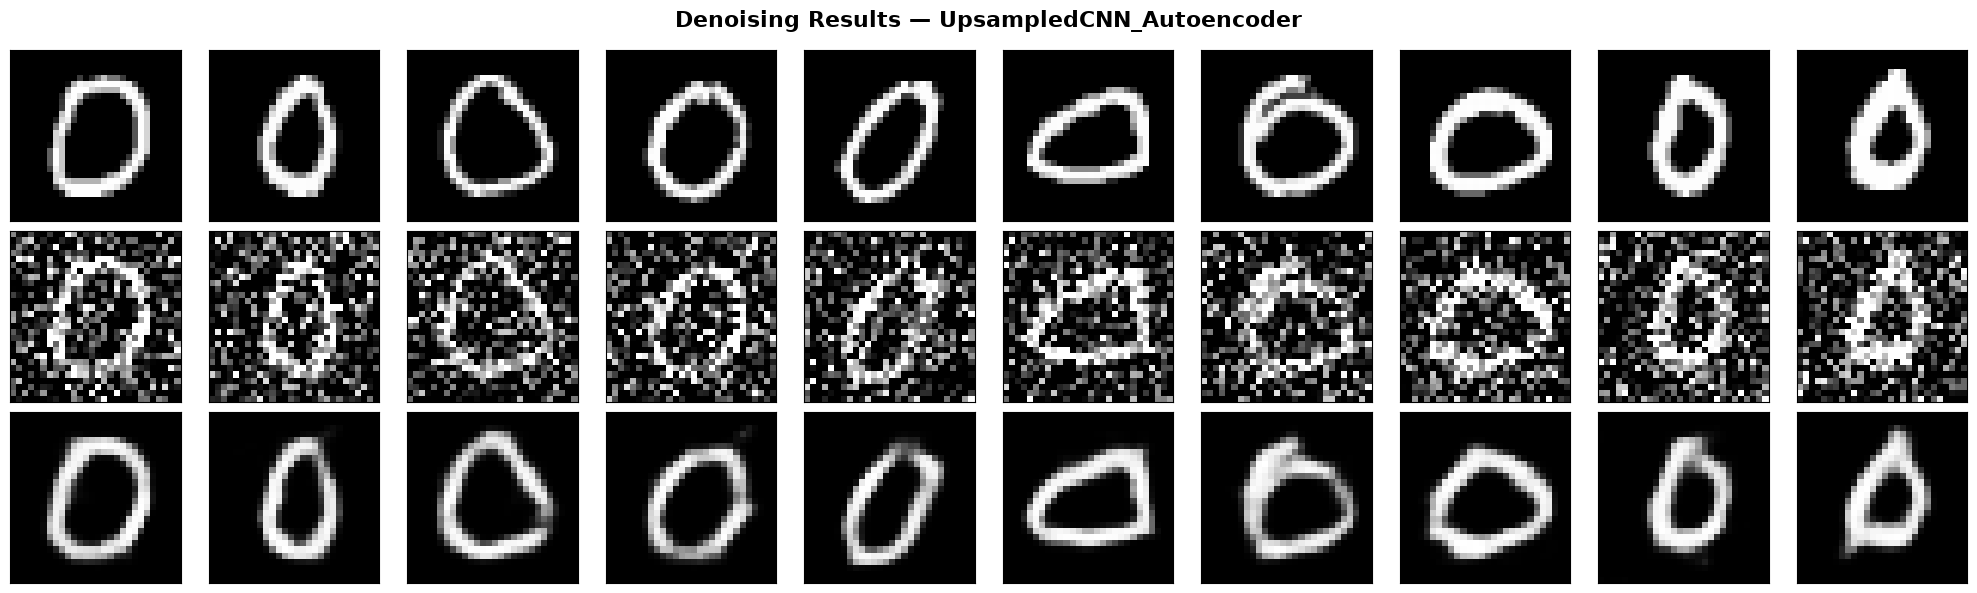

In [23]:
visualize_denoising(model_3, 'UpsampledCNN_Autoencoder')

## 18. Summary

We trained three denoising autoencoder architectures on MNIST:

| Model | Architecture | Key Feature |
|-------|-------------|-------------|
| FFNN Autoencoder | Fully connected layers | Simple, flattens images |
| Transpose CNN | Conv + ConvTranspose2d | Preserves spatial structure |
| Upsampled CNN | Conv + Upsample + Conv | Avoids checkerboard artifacts |

**Key takeaways:**
- All models successfully learn to remove Gaussian noise from images
- CNN-based models generally produce sharper denoised outputs since they preserve spatial relationships
- The Upsampled CNN avoids the checkerboard artifacts that can occur with transpose convolutions
- MSE loss is appropriate for this pixel-level regression task

In [24]:
print("\nTraining complete!")
print(f"Models saved to: {os.path.abspath(MODELS_DIR)}")
print(f"Results saved to: {os.path.abspath(RESULTS_DIR)}")


Training complete!
Models saved to: /Users/adi/Documents/celebal internship/Week6/myProject/models
Results saved to: /Users/adi/Documents/celebal internship/Week6/myProject/results
